In [20]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from cns.utils.files import *
from cns.process.binning import *
from cns.process.segments import *
from cns.process.breakpoints import *
from cns.utils.selection import *
from cns.analyze.heatmap import *
from cns.analyze.genome import *
from cns.analyze.labels import *
from cns.data_utils import load_cns_out, pjoin, out_path

# auto reload modules
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [21]:
pcawg_cns_df = load_cns_out("PCAWG_cns_imp.tsv")

In [22]:
pcawg_1_bin_df = bin_block(cns_head(pcawg_cns_df, 1), 100_000)
pcawg_1_groups_df = mean_bins(pcawg_1_bin_df)

pcawg_10_bin_df = bin_block(cns_head(pcawg_cns_df, 10), 1_000_000)
pcawg_10_groups_df = mean_bins(pcawg_10_bin_df)

pcawg_50_bin_df = bin_block(cns_head(pcawg_cns_df, 50), 10_000_000)
pcawg_50_groups_df = mean_bins(pcawg_50_bin_df)

subset_arms = bin_block(cns_head(pcawg_cns_df, 10), "arms")
subset_arms_groups = mean_bins(subset_arms)

Binning chr (23/23)
Binning chr (231/231)
Binning chr (1151/1151)
Binning chr (231/231)


In [23]:
pcawg_10_bin_df

,sample_id,chrom,start,end,major_cn,minor_cn,total_cn,length,mid,cum_mid
0,SP1003,chr1,0,1001007,2.0,2.0,4.0,1001007,500503,500503
1,SP1003,chr1,1001007,2002013,2.0,2.0,4.0,1001006,1501510,1501510
2,SP1003,chr1,2002013,3003020,2.0,2.0,4.0,1001007,2502516,2502516
3,SP1003,chr1,3003020,4004026,2.0,2.0,4.0,1001006,3503523,3503523
4,SP1003,chr1,4004026,5005033,2.0,2.0,4.0,1001007,4504529,4504529
...,...,...,...,...,...,...,...,...,...,...
30394,SP101528,chrX,150261832,151263578,1.0,0.0,1.0,1001746,150762705,3031795991
30395,SP101528,chrX,151263578,152265323,1.0,0.0,1.0,1001745,151764450,3032797736
30396,SP101528,chrX,152265323,153267069,1.0,0.0,1.0,1001746,152766196,3033799482
30397,SP101528,chrX,153267069,154268814,1.0,0.0,1.0,1001745,153767941,3034801227


(<Figure size 1200x300 with 1 Axes>,
 <Axes: title={'center': 'Total CN per bin on linear genome'}, xlabel='position on a chromosome', ylabel='Total CN'>)

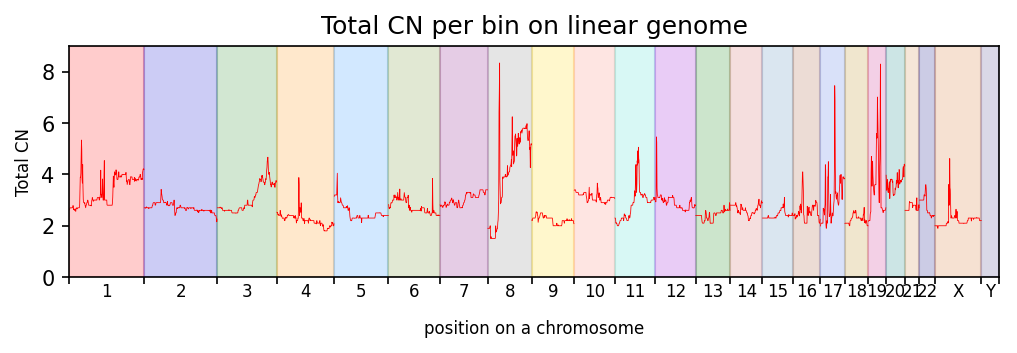

In [24]:
max_cn = np.ceil(pcawg_10_groups_df["total_cn"].max())
fig_genome(pcawg_10_groups_df, max_cn=max_cn, width=8, dpi = 150, colored=True)

In [25]:
derived = add_seg_info(load_cns("../../out/PCAWG_bin_3MB.tsv"))
derived

,sample_id,chrom,start,end,major_cn,minor_cn,total_cn,length,mid,cum_mid
0,SP1003,chr1,0,2964279,2.0,2.0,4.0,2964279,1482139,1482139
1,SP1003,chr1,2964279,5928558,2.0,2.0,4.0,2964279,4446418,4446418
2,SP1003,chr1,5928558,8892837,2.0,2.0,4.0,2964279,7410697,7410697
3,SP1003,chr1,8892837,11857116,2.0,2.0,4.0,2964279,10374976,10374976
4,SP1003,chr1,11857116,14821394,2.0,2.0,4.0,2964278,13339255,13339255
...,...,...,...,...,...,...,...,...,...,...
2661622,SP9979,chrX,140167568,143188167,1.0,1.0,2.0,3020599,141677867,3022711153
2661623,SP9979,chrX,143188167,146208765,1.0,1.0,2.0,3020598,144698466,3025731752
2661624,SP9979,chrX,146208765,149229363,1.0,1.0,2.0,3020598,147719064,3028752350
2661625,SP9979,chrX,149229363,152249962,1.0,1.0,2.0,3020599,150739662,3031772948


In [26]:
grouped = mean_bins(derived)
grouped

,cum_mid,chrom,start,end,major_cn,minor_cn,mid,length,total_cn
0,1482139,chr1,0,2964279,1.385178,0.844312,1482139,2964279,2.229490
1,4446418,chr1,2964279,5928558,1.369041,0.837592,4446418,2964279,2.206633
2,7410697,chr1,5928558,8892837,1.369844,0.834062,7410697,2964279,2.203907
3,10374976,chr1,8892837,11857116,1.373819,0.841822,10374976,2964279,2.215641
4,13339255,chr1,11857116,14821394,1.368274,0.844374,13339255,2964278,2.212648
...,...,...,...,...,...,...,...,...,...
957,3054122841,chrY,16247515,19390476,0.743963,0.000000,17818995,3142961,0.743963
958,3057265803,chrY,19390476,22533438,0.740477,0.000000,20961957,3142962,0.740477
959,3060408764,chrY,22533438,25676399,0.740715,0.000000,24104918,3142961,0.740715
960,3063551726,chrY,25676399,28819361,0.740048,0.000000,27247880,3142962,0.740048


(<Figure size 2400x600 with 1 Axes>,
 <Axes: title={'center': 'Total CN per bin on linear genome'}, xlabel='position on a chromosome', ylabel='Total CN'>)

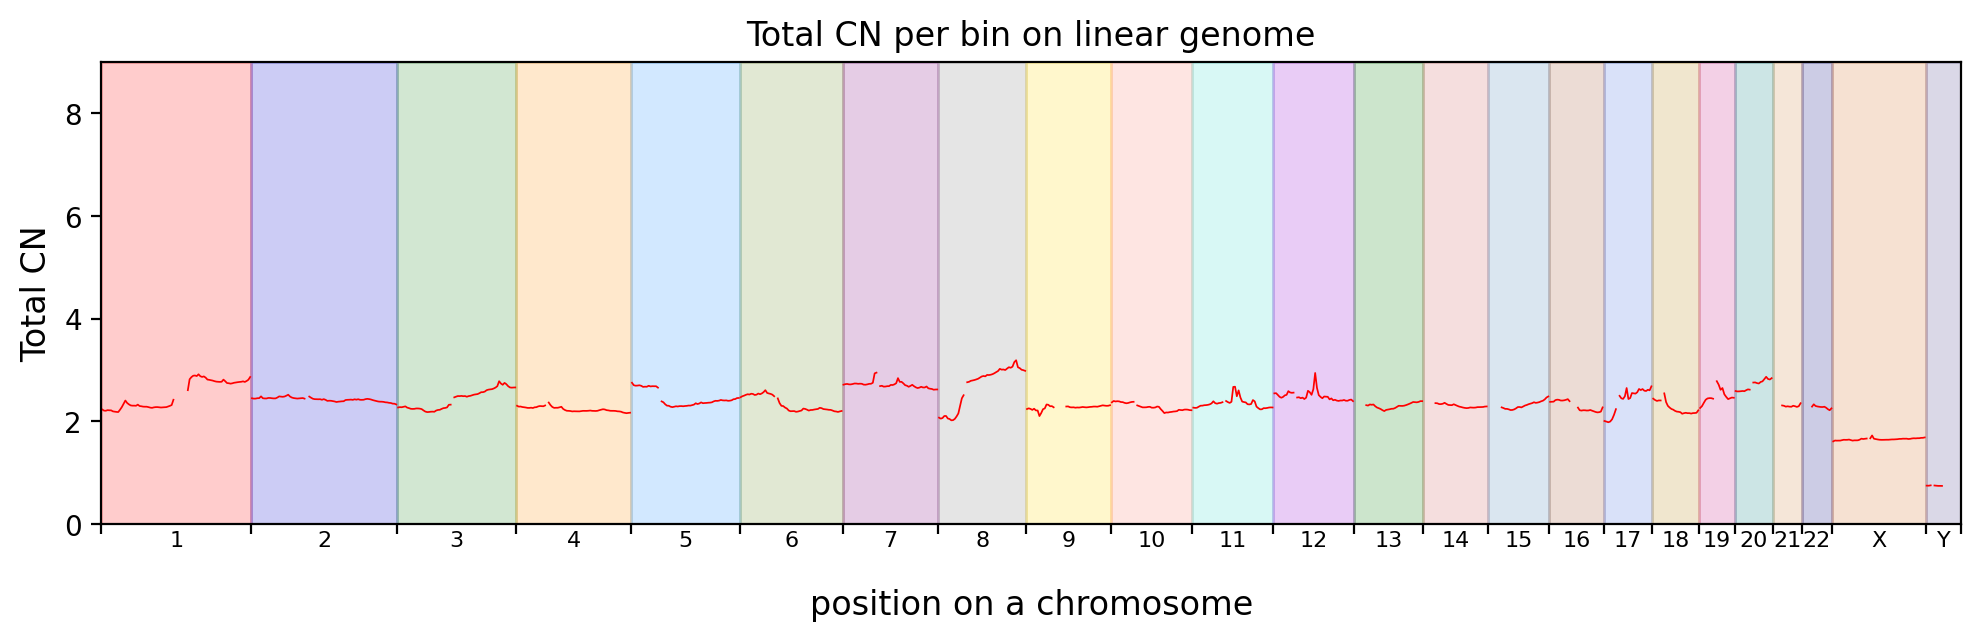

In [27]:
fig_genome(grouped, max_cn=max_cn, width=12, dpi = 200, size=.25, colored=True)

(<Figure size 1600x400 with 1 Axes>,
 <Axes: title={'center': 'Total CN per bin on linear genome'}, xlabel='position on a chromosome', ylabel='Total CN'>)

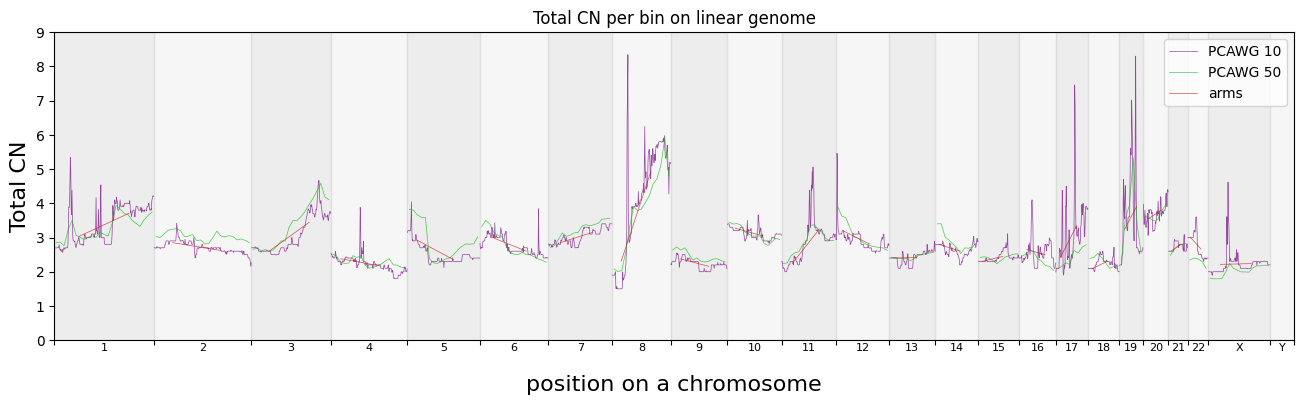

In [28]:
fig_genome_groups([pcawg_10_groups_df, pcawg_50_groups_df, subset_arms_groups], ["PCAWG 10", "PCAWG 50", "arms"], max_cn=max_cn)

(<Figure size 800x200 with 1 Axes>,
 <Axes: title={'center': 'Total CN per bin on linear genome'}, xlabel='position on a chromosome', ylabel='Total CN'>)

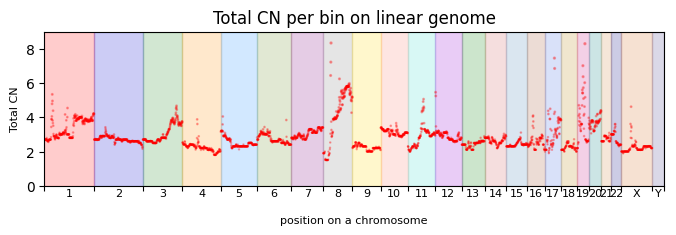

In [29]:
fig_manhattan(pcawg_10_groups_df, max_cn=max_cn, width=8, colored=True)

(<Figure size 1600x400 with 1 Axes>,
 <Axes: title={'center': 'Total CN per bin on linear genome'}, xlabel='position on a chromosome', ylabel='Total CN'>)

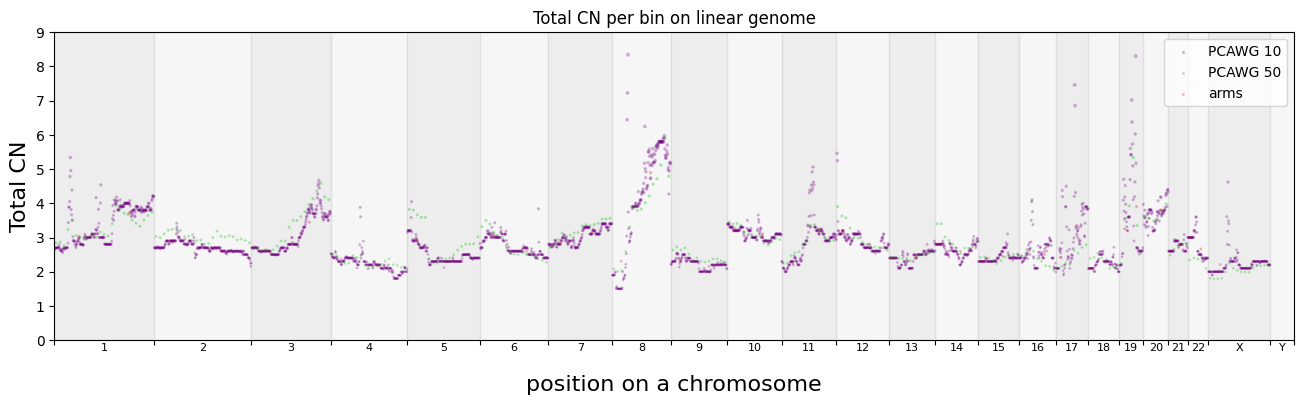

In [31]:
fig_manhattan_groups([pcawg_10_groups_df, pcawg_50_groups_df, subset_arms_groups], ["PCAWG 10", "PCAWG 50", "arms"], max_cn=max_cn)

In [32]:
step_size = int(1e6)
# only keep gaps at least half the step size
gaps_hg19_segs = tuples_to_segments(hg19.gaps)
genome_segs = genome_to_segments(hg19.chr_lens)
merged_hg19_gaps = merge_segments(gaps_hg19_segs)
filtered_gaps = filter_min_size(merged_hg19_gaps, step_size // 2)
filtered_genome = segment_difference(genome_segs, filtered_gaps)
filtered_segs = split_segments(filtered_genome, step_size)
filtered_cns = bin_by_segments(cns_head(pcawg_cns_df, 10), filtered_segs)

Binning chr (231/231)


Text(0.5, 1.0, 'Mean Copy Number across the genome, gaps removed')

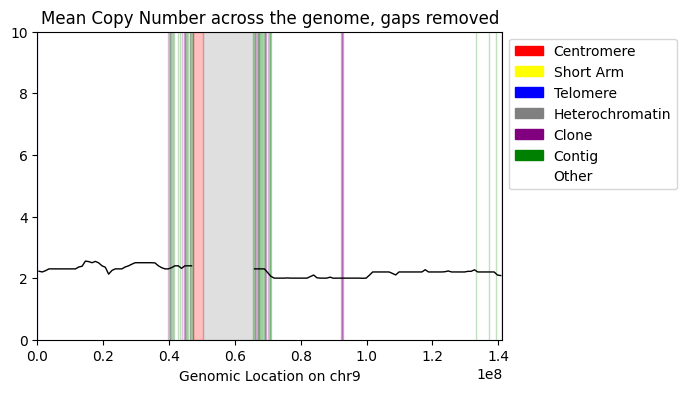

In [33]:
with_loc = add_seg_info(filtered_cns)
grouped_bins = mean_bins(with_loc)
fig, ax = plt.subplots(1, 1, figsize=(6, 4), dpi=100)
plot_gaps(ax, alpha=.25, y_max=10, sel_chrom="chr9")
add_gap_legend(ax)
line_plot(ax, grouped_bins, "total_cn", color="black", sel_chrom="chr9")
# no_y_ticks(ax)
# add lables
ax.set_xlabel("Genomic Location on chr9")
# ax.set_ylabel("Mean Copy Number")
ax.set_title("Mean Copy Number across the genome, gaps removed")

# CN Tracks

Figure size in inches: [10.   1.2] (Width x Height)
Ax size in inches: [8.43479167 0.6016003 ] (Width x Height)
Ax coordinates within the figure:
	Left: 0.07826041666666661
	Bottom: 0.2493332070831824
	Right: 0.9217395833333334
	Top: 0.7506667929168176
image_pixes:  (607, 30363)
dpi:  100
Top size:  0.125


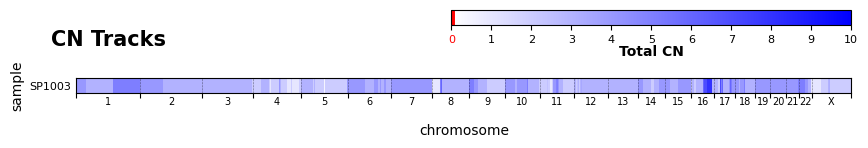

In [34]:
fig_CN_heatmap(pcawg_1_bin_df, print_info=True, dpi=100)

Figure size in inches: [10.   1.2] (Width x Height)
Ax size in inches: [8.43479167 0.6016003 ] (Width x Height)
Ax coordinates within the figure:
	Left: 0.07826041666666661
	Bottom: 0.2493332070831824
	Right: 0.9217395833333334
	Top: 0.7506667929168176
image_pixes:  (607, 30363)
dpi:  100
Top size:  0.125


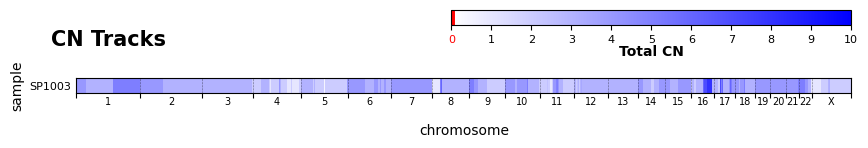

In [35]:
fig_CN_heatmap(pcawg_1_bin_df, print_info=True)

Figure size in inches: [10.  3.] (Width x Height)
Ax size in inches: [8.57729167 2.06125   ] (Width x Height)
Ax coordinates within the figure:
	Left: 0.07113541666666662
	Bottom: 0.1564583333333333
	Right: 0.9288645833333333
	Top: 0.8435416666666666
image_pixes:  (10, 48)
dpi:  100
Top size:  0.05


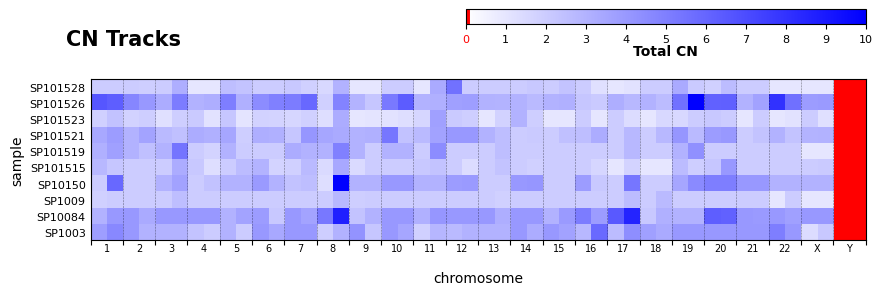

In [36]:
fig_CN_heatmap(subset_arms, width=10, print_info=True)

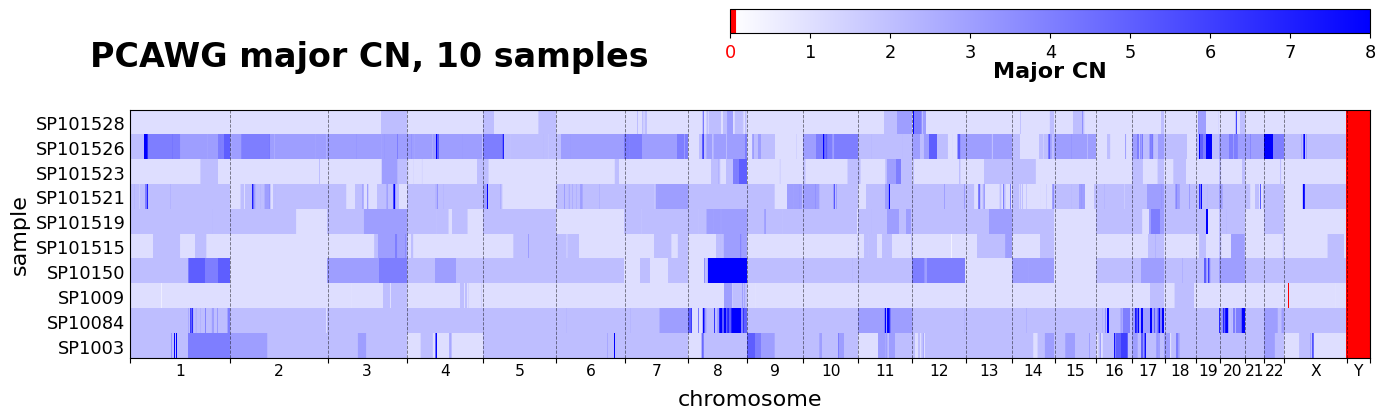

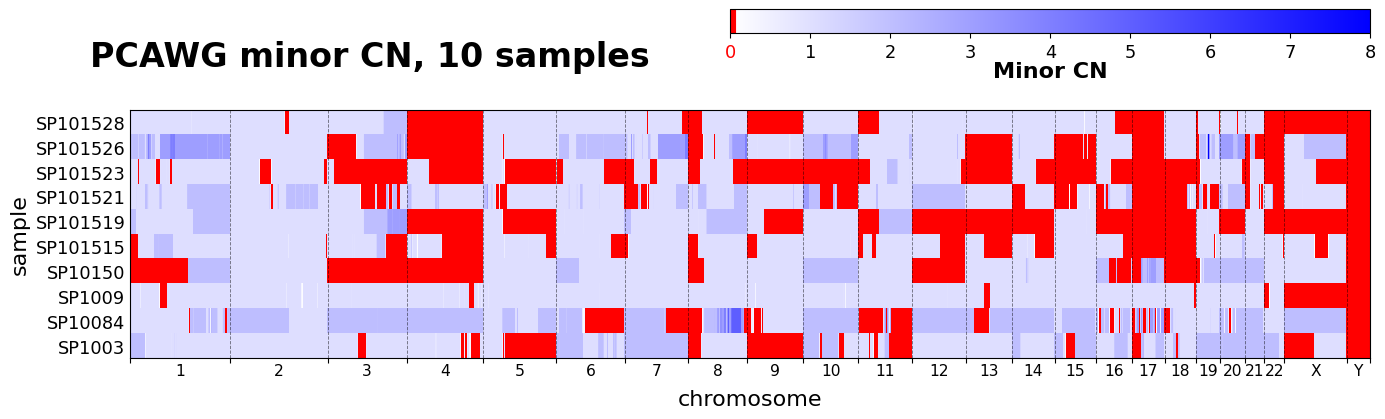

In [37]:
fig_CN_heatmap(pcawg_10_bin_df, "PCAWG major CN, 10 samples", width=16, cn_column="major_cn", max_cn=8)
fig_CN_heatmap(pcawg_10_bin_df, "PCAWG minor CN, 10 samples", width=16, cn_column="minor_cn", max_cn=8)

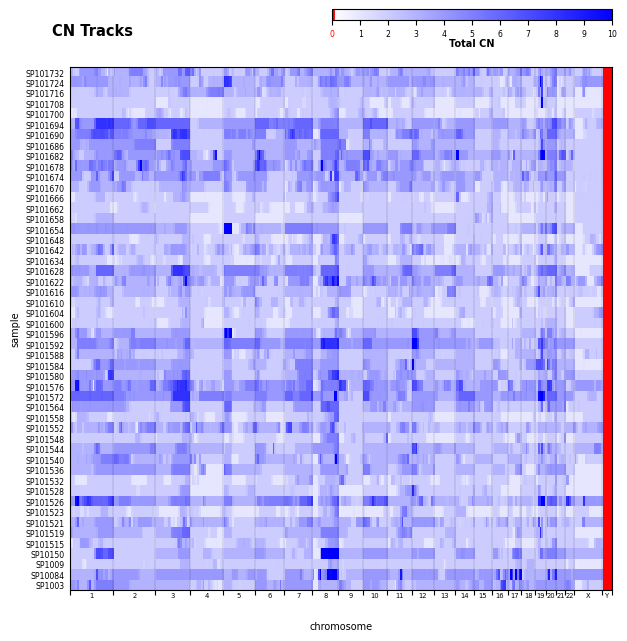

In [38]:
fig_CN_heatmap(pcawg_50_bin_df, width=7)

In [39]:
pcawg_500_bin_df = bin_block(cns_head(pcawg_cns_df, 500), 10_000_000)
print("Creating heatmap.... ")
fig_CN_heatmap(pcawg_500_bin_df, vertical_legend_correction=0.0025);
# create directory out if not exist

plt.savefig(pjoin(out_path, "pcawg_500_tracks.png"), dpi=150)
plt.close()

Binning chr (11784/11784)
Creating heatmap.... 
